# Coleta dos dados utilizando API

In [12]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Coleta dos dados via API

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": "365"}

response = requests.get(url, params=params)

if response.status_code != 200:
    raise Exception("Erro ao coletar dados da API")

data = response.json()

prices = data['prices']
df = pd.DataFrame(prices, columns=['timestamp', 'price'])

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.set_index('timestamp')

# Garante frequência diária

df = df.resample("D").mean()

df.head(10)

,price
timestamp,
2025-03-04,86124.714187
2025-03-05,87310.805311
2025-03-06,90604.080985
2025-03-07,90001.400876
2025-03-08,86773.335976
2025-03-09,86142.983359
2025-03-10,80751.138933
2025-03-11,78783.940579
2025-03-12,82799.108029


# Limpeza e ajuste dos dados

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2025-03-04 to 2026-03-03
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [14]:
df.describe()

,price
count,365.000000
mean,98669.937880
std,14975.449426
min,62853.690384
25%,87327.729697
50%,102290.137147
75%,110997.804371
max,124773.508231


In [15]:
df.isna().sum()

,0
price,0


# Análise exploratória dos dados



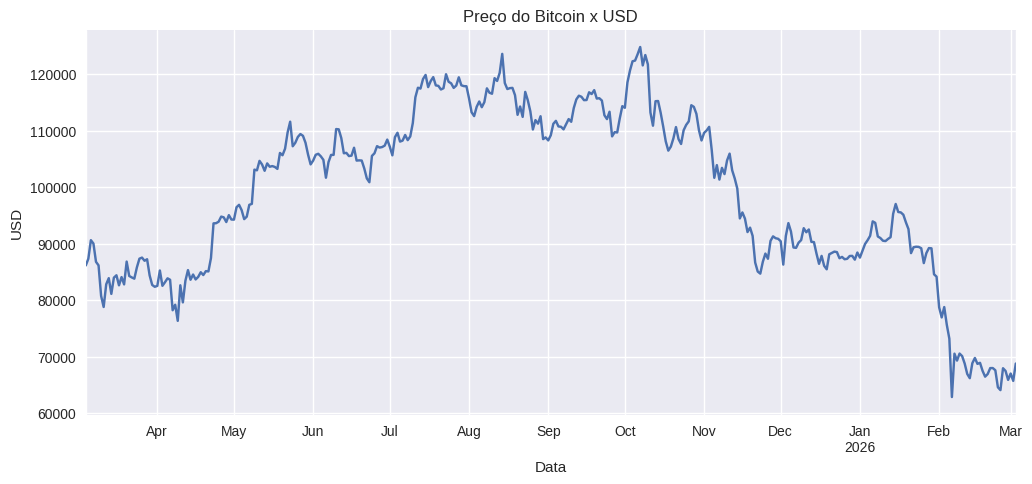

In [16]:
df['price'].plot(figsize=(12, 5))

plt.title("Preço do Bitcoin x USD")
plt.xlabel("Data")
plt.ylabel("USD")

plt.show()

O gráfico mostra o valor do Bitcoin em dólar ao longo do tempo.

Com essa visualização podemos entender os maiores picos e baixas do valor.

### Retornos Diários

Essa é a fórmula para calucular o retorno diário.

Quanto o preço caiu/subiu de um dia para o outro em %.

In [17]:
df['return'] = df['price'].pct_change()
df['log_return'] = np.log(df['price'] / df['price'].shift(1))

####Visualização de Preço + Retorno

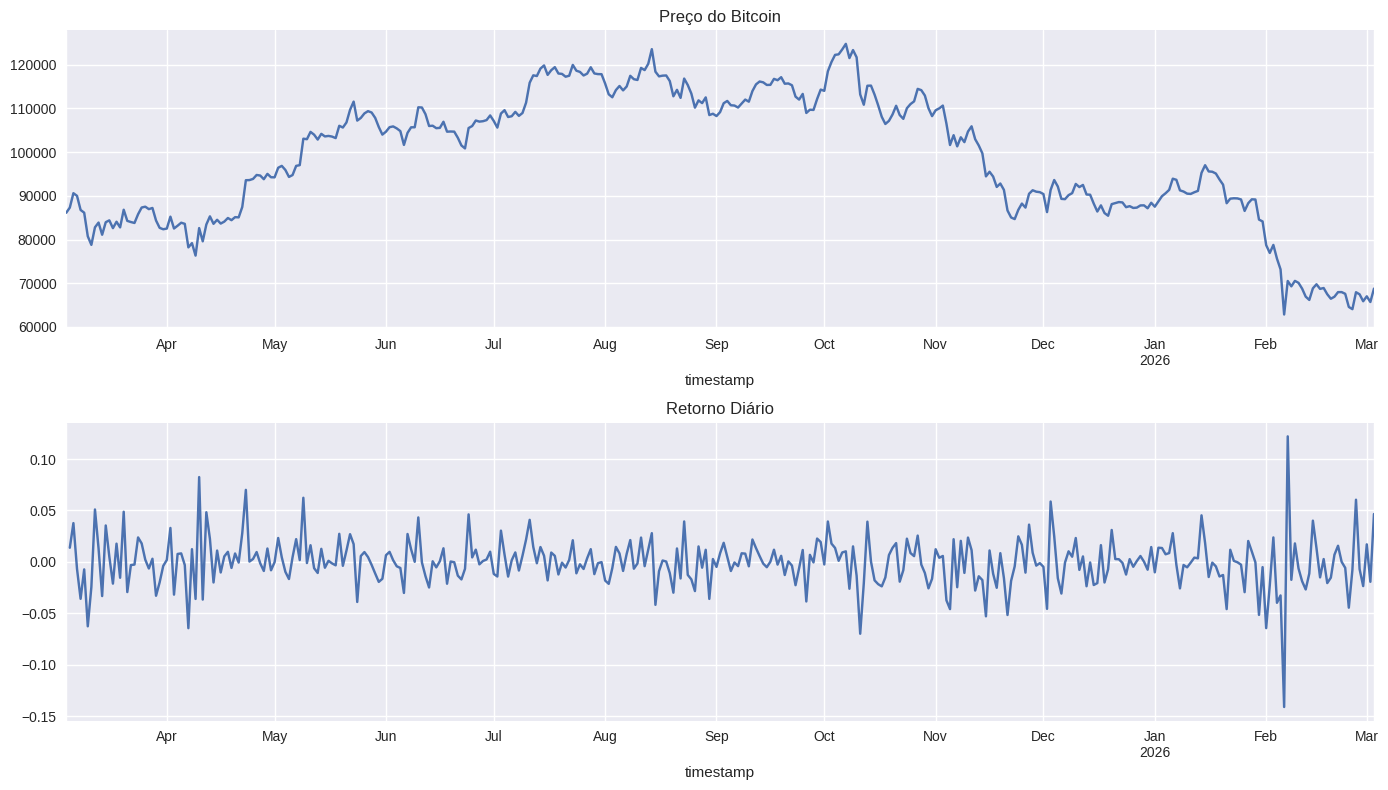

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(14,8))

df['price'].plot(ax=ax[0])
ax[0].set_title("Preço do Bitcoin")

df['return'].plot(ax=ax[1])
ax[1].set_title("Retorno Diário")

plt.tight_layout()
plt.show()

####Distribuição dos Retornos

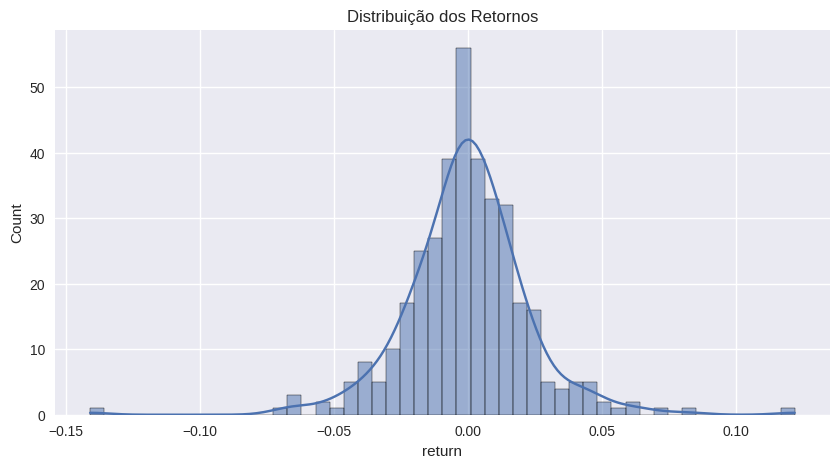

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['return'].dropna(), bins=50, kde=True)

plt.title("Distribuição dos Retornos")
plt.show()

Com as barras próximas de zero, podemos entender que a variação do retorno foi baixa. Isso significa que na maior parte dos dias o valor variou pouco.

Mesmo o Bitcoin tendo grande volatilidade, com esse gráfico, podemos entender que o retorno médio diário tende a ser pequeno. Os dias "normais" ainda são maiores do que os dias extremos.

Com os valores extremos, como de exemplo 0.15 (15%) no gráfico, podemos ver que se tratando de Bitcoin, os eventos extremos ainda acontecem mais do que deveriam. Isso evidencia o alto risco de investimento nesse mercado.

####Volatilidade Rolling

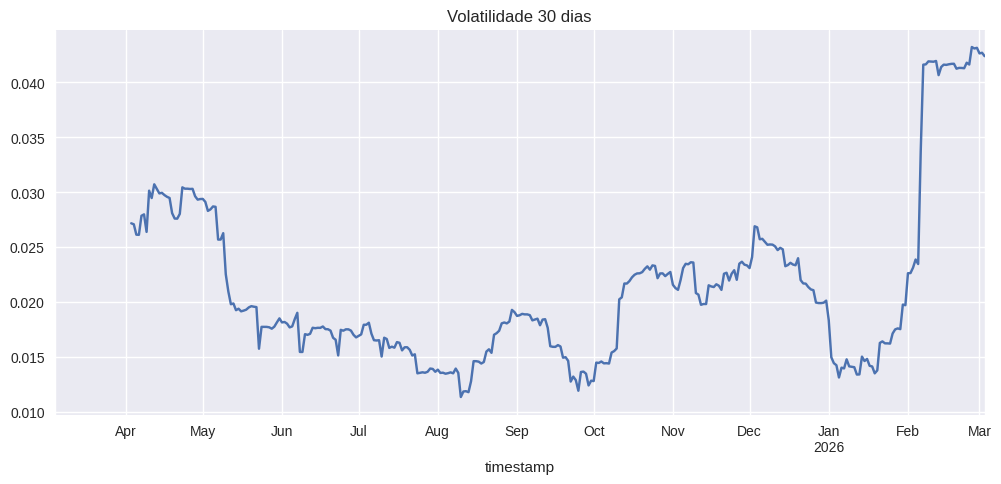

In [20]:
df['volatility_30'] = df['return'].rolling(30).std()

df['volatility_30'].plot(figsize=(12,5))
plt.title("Volatilidade 30 dias")
plt.show()

O gráfico mostra a volatilidade, ou, o quanto o préco oscila nos últimos 30 dias.

Com isso, podemos entender se durante os últimos 30 dias, o valor estava mais estável ou variando mais.

Uma alta volatilidade mostra que o preço está variando muito e o mercado está agitando. Já a volatilidade mais baixa, mostra o contrário, menor variação no valor e menos agitação do mercado.

#### Drawdown

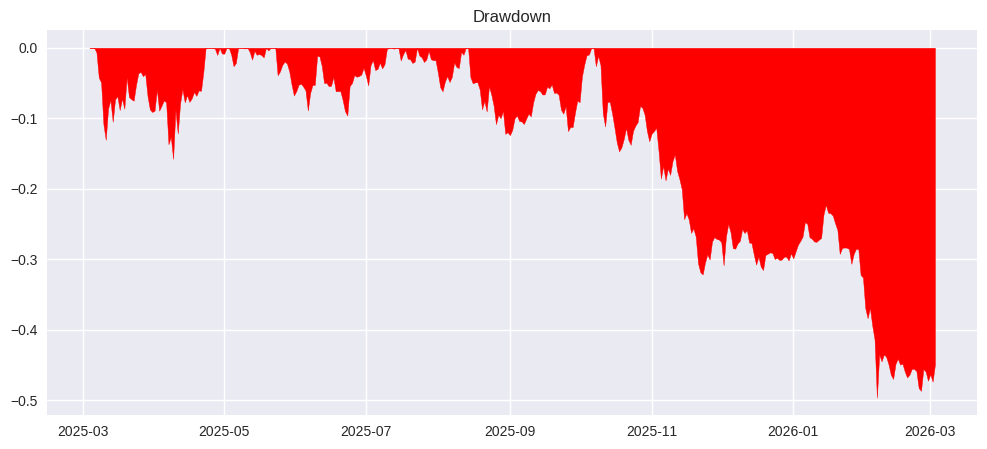

In [21]:
df['cummax'] = df['price'].cummax()
df['drawdown'] = (df['price'] - df['cummax']) / df['cummax']

plt.figure(figsize=(12,5))
plt.fill_between(df.index, df['drawdown'], color='red')
plt.title("Drawdown")
plt.show()

O drawdown é um dos indicadores mais importantes dentro do mercado financeiro.
Esse indicador mede o quanto o preço caiu em relação ao maior pico anterior.

O código faz isso guardando o valor máximo anterior e depois, calcula o quanto o preço atual está abaixo desse pico.

As áreas mais próximas do 0 no gráfico mostra que o valor está muito próximo ou atingiu o valor histórico. Quanto mais distante, mais longe o valor está do máximo, ou seja, se encontra em queda.

No gráfico, podemos ver uma seção entre 0.4 e 0.5, isso significa que naquele período o valor estava entre 4% e 5% mais baixo do que a máxima.

#### Valor X Média Móvel

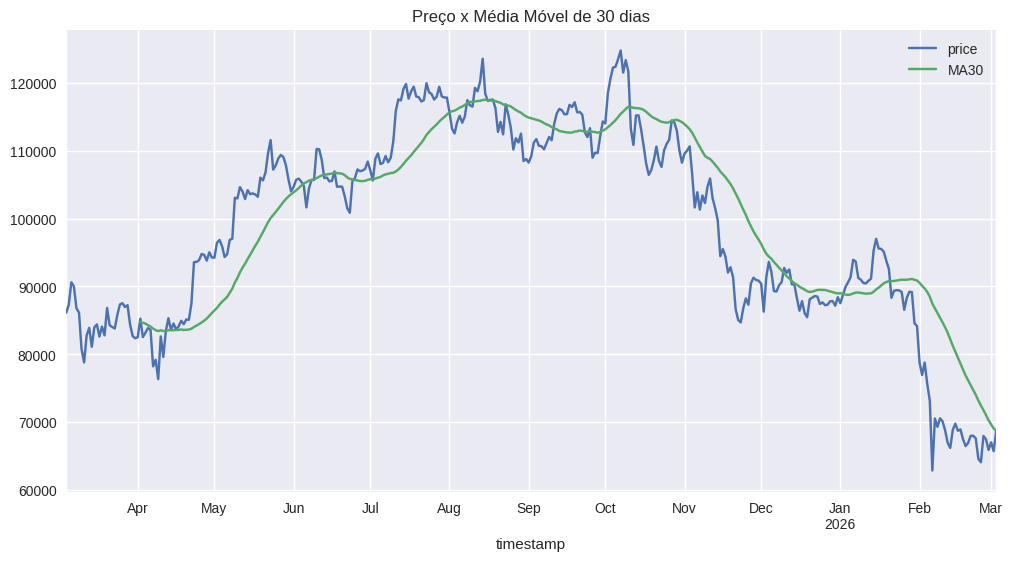

In [22]:
df['MA30'] = df['price'].rolling(window=30).mean()
df[['price', 'MA30']].plot(figsize=(12, 6))

plt.title("Preço x Média Móvel de 30 dias")
plt.show()

A média móvel seria a média do preço dos últimos n dias, nesse caso a análise é feita sob 30 dias.

A média móvel nos proporciona uma visão mais clara da tendência em geral, removendo o "ruído" que existe da tendência principal, mostrando uma linha lisa.

Quando o valor, ou, linha principal está maior do que a linha secundária, que indica a média móvel, significa que o mercado está mais forte, em tendência de alta. Quando o contrário ocorre, indica que o mercado está mais fraco, com uma tendência de baixa.

Com isso, podemos identificar possíveis sinais de reversão, mudança de direção e outras informações importantes.

Um outro ponto de atenção é o cruzamento entre as duas linhas, que pode indicar um início de uma tendência de alta ou baixa.
